In [1]:
import sys
sys.path.append('../../..')

from src import utils
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# MongoDB connection


client = MongoClient('mongodb://localhost:27017/')
db = client['MAC_SC_R=1_2']

phase1_col = db['destination, phase_1']
# phase2_col = db['destination, phase_2']

# Target MAC
TARGET_MAC = '3f8cd3da0bf84566839a7c790889884bab003e2de42c45d822188c14e1fbb719'
phase1_col.find_one({}).keys()

/home/moh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-05-11 23:01:54.570408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-11 23:01:54.583322: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747022514.597311  132341 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for

dict_keys(['_id', 'SNR', 'message', 'time', 'r0', 'r1', 'r_half', 'decoded_phase_2', 'config'])

In [2]:
r0 = {}
r1 = {}
r_half = {}
alpha = {}

indx = 0
for doc in phase1_col.find({}):
    # if doc['SNR'] > 5:
    #     print(doc['SNR'],indx)
    #add doc['r0'] to r0
    #add doc['r1'] to r1
    #add doc['r_half'] to r_half
    r0[indx] = np.array(doc['r0'])
    r1[indx] = np.array(doc['r1'])
    r_half[indx] = np.array(doc['r_half'])
    alpha[indx] = doc['config']['ALPHA']
    indx += 1

# r0 = pd.DataFrame.from_dict(r0, orient='index')
# r1 = pd.DataFrame.from_dict(r1, orient='index')
# r_half = pd.DataFrame.from_dict(r_half, orient='index')


In [3]:
log_r0_r1 = []

for i in range(len(r0)):
    log_r0_r1.extend(np.log10(r0[i] / r1[i]))


105972469 45995 2304 105972480


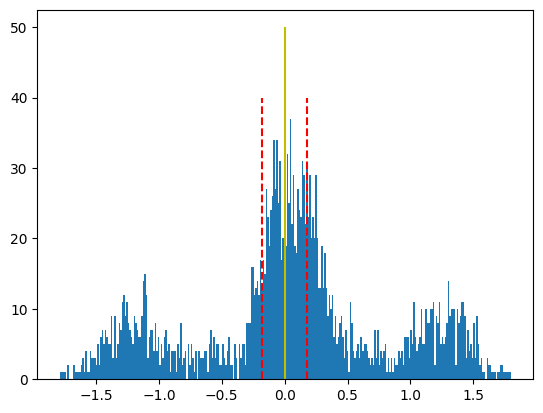

In [4]:
print(len(log_r0_r1), len(r0), len(r0[0]),  len(r0)* len(r0[0]))
i =41471
delta = 0.0
ALPHA = alpha[i]
plt.hist(log_r0_r1[i*2304:2304*(i+1)], bins=300)
plt.vlines(x=np.log10(ALPHA/(1-ALPHA))+delta, ymin=0, ymax= 40, color='r', linestyle='--')
plt.vlines(x=np.log10((1-ALPHA)/ALPHA)-delta, ymin=0, ymax= 40, color='r', linestyle='--')
plt.vlines(x=0, ymin=0, ymax= 50, color='y', linestyle='-')

In [ ]:
# hard decoded based on the llr
i =0


m = np.array(log_r0_r1[2304*i:2304*(i+1)],dtype=np.int8) >0

utils.bits_to_string(m.astype(np.int8))

'\x00\x060@\x00\x00\x84\x00\x00LÀ\x00\x84 ÔT´P`\x18\x84`@$\x08\x80\x00\x00\x00 \x00\x00\x80\x02\x16\x16 \x00@\x00\x00\x00\x04\x80\x80\x00\x00\x00\r\x80F\x00\x04\x00\x1c\x94\x00\x00\x00\x08\x00\x00\x00\x00 \x04\x00 \x90\x94è\x04\x94\x18\x00\x08\x14\x10\x00\x00\x10\x90\x00\x04\x80ÈHH\x03\x00\x96@\x00\x00\x00P\x804\x00\x00\t\x08\x80`\x00\x01A\x80!q\x90ÊA\x04\x00\x00\x80\x03\x01A\x01\x88\x00\x00\x00\x00\t\x82`Ðf\x10\x00\x05\x02\x80D\x0c\x00@\x00\x80\x00\x00\x04\xa0H\rX²\xa0\x00\x00&@\x07\x00\x08@\x11\x1c\x80\x08\x01ä\x06\x08\x00\x00\x11\x08h@\x044@ \x19$\x10\x02\x80\x00\x10eÀ\x00\x00\n\t\x02\t Q\x80\x00\x10\x00`\x00\x00\x18\x80\tP\x04\x80\x00\x00ð! \x00\x08\x12"\x81V\x00\xa0 \x00\x01\xad\x00H\x00x@\x00\x01\x00\x04°\x03á\x00H\x00\x00\x00@À\x00\x12H\x10\x00\x10 \x10Õ`\x04(\x00\x00\x08\x00\x00\x00ª\x00@(à Â\x01B\x00\x00\x00\x00\x04\x80\x00\x03\x02\x00\x00(\x00\x00@\x12X\x10'

In [5]:
#!/usr/bin/env python3
import numpy as np
from gnuradio import gr, blocks, digital, channels

class BPSKLoopback(gr.top_block):
    def __init__(self,
                 bits,
                 samp_rate=32000,
                 sps=8,
                 excess_bw=0.35,
                 noise_volt=0.0):
        super().__init__()

        # 1) Source: byte stream of bits
        src = blocks.vector_source_b(bits, repeat=False)

        # Unpack bits to one bit per byte
        unpack = blocks.unpack_k_bits_bb(1)

        # 2) BPSK modulator: RRC filter
        mod = digital.bpsk.generic_mod(
            mod_code=None,
            differential=False,
            samples_per_symbol=sps,
            excess_bw=excess_bw,
            verbose=False,
            log=False
        )  # :contentReference[oaicite:4]{index=4}

        # 3) Channel: AWGN (optional)
        chan = channels.channel_model(
            noise_voltage=noise_volt,
            frequency_offset=0.0,
            taps=[1.0],
            noise_seed=42
        )  # :contentReference[oaicite:5]{index=5}

        # 4) Carrier recovery: Costas Loop for BPSK
        costas = digital.costas_loop_cc(2.0, 2, False)  # loop_bw=2.0, order=2 :contentReference[oaicite:6]{index=6}

        # 5) Clock recovery: Mueller–Müller timing
        mm = digital.clock_recovery_mm_cc(
            omega=sps,
            gain_omega=0.25 * 0.175 * 0.175,
            mu=0.5,
            gain_mu=0.175,
            omega_rel=0.005
        )  # :contentReference[oaicite:7]{index=7}

        # 6) Demodulator: RRC‑filtered BPSK demod
        demod = digital.bpsk_demod(
            mod_code=None,
            differential=False,
            samples_per_symbol=sps,
            excess_bw=excess_bw,
            verbose=False,
            log=False
        )  # :contentReference[oaicite:8]{index=8}

        # Pack bits back into bytes
        pack = blocks.pack_k_bits_bb(1)

        # 7) Sink: collect output bits
        sink = blocks.vector_sink_b()

        # Connect flowgraph
        self.connect(src, unpack, mod, chan, costas, mm, demod, pack, sink)
        self.sink = sink

    def run_and_get(self):
        self.run()
        return list(self.sink.data())

if __name__ == "__main__":
    # generate random bits
    bits_in = list(np.random.randint(0, 2, 1000))
    tb = BPSKLoopback(bits_in, noise_volt=0.1)
    bits_out = tb.run_and_get()

    # compute BER
    errors = sum(b1 != b2 for b1, b2 in zip(bits_in, bits_out))
    print(f"Input bits : {bits_in[:32]}...")
    print(f"Output bits: {bits_out[:32]}...")
    print(f"Bit errors : {errors} / {len(bits_in)}  (BER = {errors/len(bits_in):.3f})")



TypeError: generic_mod.__init__() got an unexpected keyword argument 'mod_code'

In [ ]:
FSKdemod = digital.gfsk_demod(
    samples_per_symbol=10,
    sensitivity=2.0,
    bt=0.5,
    verbose=False,
    log=False
)

FSKdemod.